In [2]:
!git clone https://github.com/faranbutt/Graph4ASD-Challenge.git

Cloning into 'Graph4ASD-Challenge'...
remote: Enumerating objects: 685, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 685 (delta 112), reused 118 (delta 68), pack-reused 494 (from 2)
Receiving objects: 100% (685/685), 148.36 KiB | 4.01 MiB/s, done.
Resolving deltas: 100% (371/371), done.
Filtering content: 100% (4/4), 388.79 MiB | 21.32 MiB/s, done.


In [3]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.3 MB/s eta 0:00:00


In [4]:
import time
import copy
import platform
import pandas as pd
import numpy as np
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv, global_mean_pool, SAGEConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dense_to_sparse, to_undirected
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

In [5]:
SEED = 25
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [7]:
print(f"Pytorch Version  = {torch.__version__}")
print(f"OS  = {platform.system()} {platform.release()}")
print(f"Processor = {platform.processor()}")

Pytorch Version  = 2.10.0+cu128
OS  = Linux 6.6.113+
Processor = x86_64


In [8]:
START_TIME = time.time()

In [9]:
#Train
train_labels = pd.read_csv('/content/Graph4ASD-Challenge/data/public/train_label.csv')
train_adj = np.load('/content/Graph4ASD-Challenge/data/public/adj_train.npy')
train_node_feat= np.load('/content/Graph4ASD-Challenge/data/public/node_features_train.npy')

#Test
test_adj= np.load('/content/Graph4ASD-Challenge/data/public/adj_test.npy')
test_node_feat = np.load('/content/Graph4ASD-Challenge/data/public/node_features_test.npy')

In [10]:
print(f"Train adj shape: {train_adj.shape}")
print(f"Test adj shape: {test_adj.shape}")
print(f"Train node features shape: {train_node_feat.shape}")
print(f"Test node features shape: {test_node_feat.shape}")
print(f"Train labels shape: {train_labels.shape}")

Train adj shape: (484, 200, 200)
Test adj shape: (153, 200, 200)
Train node features shape: (484, 200, 200)
Test node features shape: (153, 200, 200)
Train labels shape: (484, 2)


In [11]:
class_counts = np.bincount(train_labels['label'])
print(f"Class distribution: ASD = {class_counts[1]}, TC = {class_counts[0]}")
print(f"Train positive ratio: {class_counts[1]/len(train_labels):.3f}")

Class distribution: ASD = 252, TC = 232
Train positive ratio: 0.521


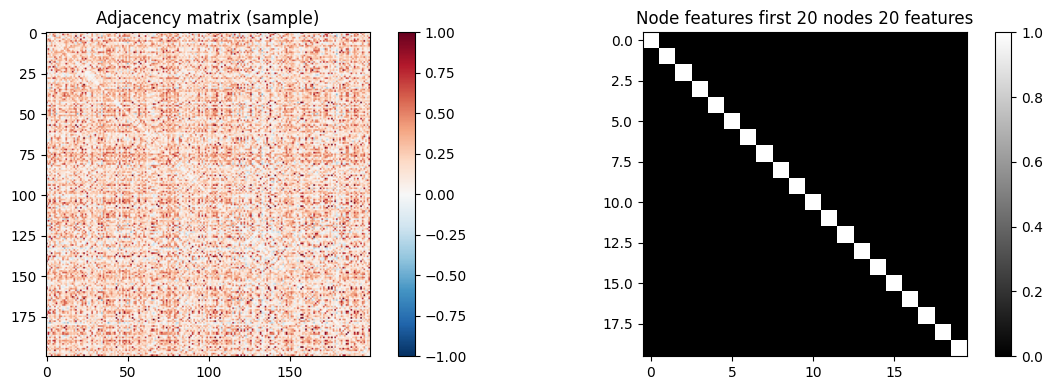

In [12]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(train_adj[0], cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Adjacency matrix (sample)')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(train_node_feat[0][:20,:20], cmap='gray')
plt.title('Node features first 20 nodes 20 features')
plt.colorbar()
plt.tight_layout()
plt.show()

In [13]:
print("Diagnoal Mean ",np.diag(train_node_feat[0]).mean())
print(f"Off-diagonal mean: {(train_node_feat[0] - np.diag(np.diag(train_node_feat[0]))).mean():.4f}")

Diagnoal Mean  1.0
Off-diagonal mean: 0.0000


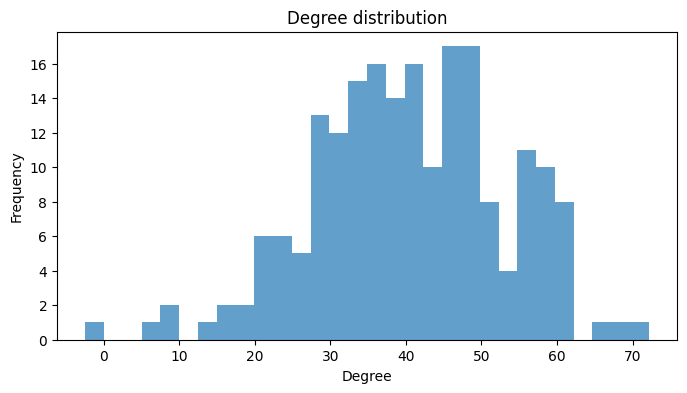

In [14]:
adj_s = train_adj[0]
degrees = adj_s.sum(axis=1)
plt.figure(figsize=(8,4))
plt.hist(degrees, bins=30, alpha=0.7)
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree distribution')
plt.show()


In [15]:
train_adj.shape

(484, 200, 200)

In [16]:
y_train = train_labels['label'].values.astype(np.int64)

In [17]:
def load_graph(adj, node_feat, y=None):
    data_list = []
    for i in range(len(adj)):
        adj_t = torch.tensor(adj[i], dtype=torch.float)
        adj_t = (adj_t + 1) / 2
        edge_index, edge_attr = dense_to_sparse(adj_t)
        edge_index, edge_attr = to_undirected(edge_index, edge_attr, num_nodes=adj_t.shape[1])
        x = torch.tensor(node_feat[i], dtype=torch.float)
        if y is not None:
            label = torch.tensor([y[i]], dtype=torch.long)
        else:
            label = torch.tensor([-1], dtype=torch.long)
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=label)
        data_list.append(data)
    return data_list

In [18]:
train_graphs = load_graph(train_adj,train_node_feat,y_train)

In [19]:
sss = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=SEED)
train_idx, val_idx = next(sss.split(np.arange(len(train_graphs)), y_train))

In [20]:
train_data = [train_graphs[i] for i in train_idx]
val_data = [train_graphs[i] for i in val_idx]

In [21]:
print(f"Train graphs: {len(train_data)}, Val graphs: {len(val_data)}")

Train graphs: 387, Val graphs: 97


In [22]:
test_graphs = load_graph(test_adj,test_node_feat)

In [23]:
train_loader = DataLoader(train_data,batch_size=32,shuffle=True)
val_loader = DataLoader(val_data,batch_size=32,shuffle=False)
test_loader = DataLoader(test_graphs,batch_size=32,shuffle=False)

# Models

In [24]:

class GCN(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels,num_layers,dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GCNConv(in_channels,hidden_channels))
    self.bns.append(nn.BatchNorm1d(hidden_channels))


    for i in range(num_layers-1):
      self.convs.append(GCNConv(hidden_channels,hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))
    self.classifier = nn.Sequential(
        nn.Linear(hidden_channels,hidden_channels // 2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_channels // 2, out_channels)
    )
  def forward(self,data):
    x,edge_index,edge_w,batch = data.x, data.edge_index, data.edge_attr, data.batch
    for i,conv in enumerate(self.convs):
      x = conv(x,edge_index,edge_weight=edge_w)
      x = self.bns[i](x)
      x = F.relu(x)
      x = F.dropout(x,p=self.dropout,training=self.training)
    x = global_mean_pool(x,batch)
    return self.classifier(x)


In [25]:
class GraphSAGE(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels,num_layers,dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(SAGEConv(in_channels,hidden_channels))
    self.bns.append(nn.BatchNorm1d(hidden_channels))


    for i in range(num_layers-1):
      self.convs.append(SAGEConv(hidden_channels,hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))
    self.classifier = nn.Sequential(
        nn.Linear(hidden_channels,hidden_channels // 2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_channels // 2, out_channels)
    )
  def forward(self,data):
    x,edge_index,batch = data.x, data.edge_index, data.batch
    for i,conv in enumerate(self.convs):
      x = conv(x,edge_index)
      x = self.bns[i](x)
      x = F.relu(x)
      x = F.dropout(x,p=self.dropout,training=self.training)
    x = global_mean_pool(x,batch)
    return self.classifier(x)


In [26]:
class GAT(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels,heads,num_layers,dropout=0.6):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GATv2Conv(in_channels, hidden_channels, heads=heads, concat=True, dropout=dropout))
    self.bns.append(nn.BatchNorm1d(hidden_channels * heads))
    for _ in range(num_layers - 2):
        self.convs.append(GATv2Conv(hidden_channels * heads, hidden_channels, heads=heads, concat=True, dropout=dropout))
        self.bns.append(nn.BatchNorm1d(hidden_channels * heads))
    if num_layers > 1:
        self.convs.append(GATv2Conv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=dropout))
        final_dim = hidden_channels
    else:
        self.convs.append(GATv2Conv(in_channels, hidden_channels, heads=1, concat=False, dropout=dropout))
        final_dim = hidden_channels
    self.classifier = nn.Sequential(
        nn.Linear(final_dim, final_dim // 2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(final_dim // 2, out_channels)
    )
  def forward(self, data):
    x, edge_index, batch = data.x, data.edge_index, data.batch
    for i, conv in enumerate(self.convs):
        x = conv(x, edge_index)
        if i < len(self.bns):
            x = self.bns[i](x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
    x = global_mean_pool(x, batch)
    return self.classifier(x)

In [27]:
def train(model, loader, optimizer, criterion):
  model.train()
  total_loss = 0
  for data in loader:
      data = data.to(device)
      optimizer.zero_grad()
      out = model(data)
      target = data.y.view(-1)
      loss = criterion(out, target)
      loss.backward()
      optimizer.step()
      total_loss += loss.item() * data.num_graphs
  return total_loss / len(loader.dataset)

In [28]:
@torch.no_grad()
def evaluate(model, loader, criterion):
  model.eval()
  total_loss = 0
  all_preds = []
  all_labels = []
  for data in loader:
      data = data.to(device)
      out = model(data)
      loss = criterion(out, data.y.view(-1))
      total_loss += loss.item() * data.num_graphs
      pred = out.argmax(dim=1).cpu().numpy()
      all_preds.extend(pred)
      all_labels.extend(data.y.cpu().numpy())
  f1 = f1_score(all_labels, all_preds, average='macro')
  acc = accuracy_score(all_labels, all_preds)
  return total_loss / len(loader.dataset), f1, acc

In [29]:
def train_model(model, train_loader,val_loader, epochs, lr,weight_decay,patience):
  model = model.to(device)
  optimizer = torch.optim.Adam(model.parameters(),lr=lr, weight_decay=weight_decay)
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
  criterion = nn.CrossEntropyLoss()

  best_val_f1 = 0.0
  best_state = None
  patience_counter = 0
  history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
  start_time = time.time()

  for epoch in range(1, epochs+1):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_loss, val_f1, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"early stopping epcoh =  {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch = {epoch} |train loss = {train_loss} | val loss = {val_loss} | val _f1 = {val_f1:3f} | best validation f1 = {best_val_f1}")
  elapsed_time = time.time() - start_time
  model.load_state_dict(best_state)
  return model, best_val_f1, history, elapsed_time

In [36]:
hp_results = []
run_id = 0
print("GCN")
model_gcn = GCN(in_channels=200, hidden_channels=64, out_channels=2, num_layers=2, dropout=0.5)
best_model_gcn, best_f1_gcn, hist_gcn, t_gcn = train_model(model_gcn, train_loader, val_loader, epochs=200, lr=0.001, weight_decay=5e-4, patience=40)
hp_results.append({'run': run_id+1, 'arch': 'GCN', 'hidden': 64, 'layers': 2, 'val_f1': best_f1_gcn, 'time_sec': t_gcn})
run_id += 1

GCN
Epoch = 10 |train loss = 0.3532562527314637 | val loss = 1.6352560446434414 | val _f1 = 0.344595 | best validation f1 = 0.5388985507246378
Epoch = 20 |train loss = 0.08671683103847257 | val loss = 8.187158965572866 | val _f1 = 0.321678 | best validation f1 = 0.5388985507246378
Epoch = 30 |train loss = 0.16189094960150485 | val loss = 2.0777416868308154 | val _f1 = 0.471420 | best validation f1 = 0.5388985507246378
Epoch = 40 |train loss = 0.053144954019815734 | val loss = 2.468880593162222 | val _f1 = 0.479428 | best validation f1 = 0.6170916462178598
Epoch = 50 |train loss = 0.05897767861068095 | val loss = 7.320888873228093 | val _f1 = 0.321678 | best validation f1 = 0.6170916462178598
Epoch = 60 |train loss = 0.05110985229335706 | val loss = 1.7318657648932074 | val _f1 = 0.591689 | best validation f1 = 0.6170916462178598
Epoch = 70 |train loss = 0.028169336356944585 | val loss = 1.1804897170705893 | val _f1 = 0.628511 | best validation f1 = 0.6367041198501873
Epoch = 80 |train 

In [37]:
print("GraphSAGE")
model_sage = GraphSAGE(in_channels=200, hidden_channels=64, out_channels=2, num_layers=2, dropout=0.5)
best_model_sage, best_f1_sage, hist_sage, t_sage = train_model(model_sage, train_loader, val_loader, epochs=200, lr=0.001, weight_decay=5e-4, patience=40)
hp_results.append({'run': run_id+1, 'arch': 'GraphSAGE', 'hidden': 64, 'layers': 2, 'val_f1': best_f1_sage, 'time_sec': t_sage})
run_id += 1

GraphSAGE
Epoch = 10 |train loss = 0.6946858156867114 | val loss = 0.6929972147204212 | val _f1 = 0.344595 | best validation f1 = 0.34459459459459457
Epoch = 20 |train loss = 0.6915703924127328 | val loss = 0.6930465409436177 | val _f1 = 0.344595 | best validation f1 = 0.34459459459459457
Epoch = 30 |train loss = 0.6915434845350201 | val loss = 0.6919503795731928 | val _f1 = 0.344595 | best validation f1 = 0.34459459459459457
Epoch = 40 |train loss = 0.6931628817427682 | val loss = 0.6925081457059408 | val _f1 = 0.344595 | best validation f1 = 0.34459459459459457
early stopping epcoh =  46


In [38]:
print("GAT")
model_gat = GAT(in_channels=200, hidden_channels=64, out_channels=2, heads=4, num_layers=2, dropout=0.6)
best_model_gat, best_f1_gat, hist_gat, t_gat = train_model(model_gat, train_loader, val_loader, epochs=200, lr=0.001, weight_decay=5e-4, patience=40)
hp_results.append({'run': run_id+1, 'arch': 'GAT', 'hidden': 64, 'heads': 4, 'layers': 2, 'val_f1': best_f1_gat, 'time_sec': t_gat})
run_id += 1

GAT
Epoch = 10 |train loss = 0.696936474290005 | val loss = 0.6918270096336443 | val _f1 = 0.344595 | best validation f1 = 0.34459459459459457
Epoch = 20 |train loss = 0.695146847602933 | val loss = 0.6919228108887819 | val _f1 = 0.344595 | best validation f1 = 0.34459459459459457
Epoch = 30 |train loss = 0.6919168953131644 | val loss = 0.6920600939042789 | val _f1 = 0.344595 | best validation f1 = 0.34459459459459457
Epoch = 40 |train loss = 0.6928996306673193 | val loss = 0.6921846964924606 | val _f1 = 0.344595 | best validation f1 = 0.34459459459459457
early stopping epcoh =  41


In [39]:
print("GCN v2")
model_gcn2 = GCN(in_channels=200, hidden_channels=128, out_channels=2, num_layers=3, dropout=0.5)
best_model_gcn2, best_f1_gcn2, hist_gcn2, t_gcn2 = train_model(model_gcn2, train_loader, val_loader, epochs=200, lr=0.001, weight_decay=5e-4, patience=40)
hp_results.append({'run': run_id+1, 'arch': 'GCN', 'hidden': 128, 'layers': 3, 'val_f1': best_f1_gcn2, 'time_sec': t_gcn2})
run_id += 1

GCN v2
Epoch = 10 |train loss = 0.11172287064082247 | val loss = 4.072637548151705 | val _f1 = 0.344595 | best validation f1 = 0.567350579839429
Epoch = 20 |train loss = 0.09217047568131478 | val loss = 21.1709425621426 | val _f1 = 0.344595 | best validation f1 = 0.5753456221198157
Epoch = 30 |train loss = 0.06655573536875328 | val loss = 7.199740701115006 | val _f1 = 0.321678 | best validation f1 = 0.5771398192450824
Epoch = 40 |train loss = 0.022208019263214536 | val loss = 2.693416108790132 | val _f1 = 0.435450 | best validation f1 = 0.5771398192450824
Epoch = 50 |train loss = 0.06014706758488672 | val loss = 25.25786095058795 | val _f1 = 0.321678 | best validation f1 = 0.5976958525345623
Epoch = 60 |train loss = 0.031031643928483475 | val loss = 3.234379217796719 | val _f1 = 0.353333 | best validation f1 = 0.5976958525345623
Epoch = 70 |train loss = 0.033688528208153504 | val loss = 1.893173244810596 | val _f1 = 0.583599 | best validation f1 = 0.5976958525345623
Epoch = 80 |train l

In [40]:
print("GCN v3")
model_gcn3 = GCN(in_channels=200, hidden_channels=256, out_channels=2, num_layers=3, dropout=0.5)
best_model_gcn3, best_f1_gcn3, hist_gcn3, t_gcn3 = train_model(model_gcn3, train_loader, val_loader, epochs=200, lr=0.001, weight_decay=5e-4, patience=40)
hp_results.append({'run': run_id+1, 'arch': 'GCN v3', 'hidden': 256, 'layers': 3, 'val_f1': best_f1_gcn3, 'time_sec': t_gcn3})
run_id += 1

GCN v3
Epoch = 10 |train loss = 0.09446175874858248 | val loss = 2.5981403847330626 | val _f1 = 0.433154 | best validation f1 = 0.43315444245676804
Epoch = 20 |train loss = 0.040723790647762825 | val loss = 1.4994634918330871 | val _f1 = 0.563063 | best validation f1 = 0.5936190783113116
Epoch = 30 |train loss = 0.03797282355546335 | val loss = 2.596242835841228 | val _f1 = 0.567351 | best validation f1 = 0.6061965811965812
Epoch = 40 |train loss = 0.03315073317662844 | val loss = 1.6078634876565836 | val _f1 = 0.618394 | best validation f1 = 0.61839447102605
Epoch = 50 |train loss = 0.11257605836064932 | val loss = 5.801992691669268 | val _f1 = 0.344595 | best validation f1 = 0.61839447102605
Epoch = 60 |train loss = 0.08907345129845987 | val loss = 4.981276699902307 | val _f1 = 0.321678 | best validation f1 = 0.61839447102605
Epoch = 70 |train loss = 0.03985935997083129 | val loss = 5.658231833546432 | val _f1 = 0.344595 | best validation f1 = 0.61839447102605
early stopping epcoh = 

In [41]:
hp_df = pd.DataFrame(hp_results)
hp_df

,run,arch,hidden,layers,val_f1,time_sec,heads
0,1,GCN,64,2,0.639022,95.854497,NaN
1,2,GraphSAGE,64,2,0.344595,28.311894,NaN
2,3,GAT,64,2,0.344595,163.694767,4.0
3,4,GCN,128,3,0.659794,310.104678,NaN
4,5,GCN v3,256,3,0.618394,221.379315,NaN


# Submission via Best Model:





In [42]:
best_model_gcn2.eval()
test_preds = []
with torch.no_grad():
  for data in test_loader:
      data = data.to(device)
      out = best_model_gcn2(data)
      pred = out.argmax(dim=1).cpu().numpy()
      test_preds.extend(pred)

In [51]:
submission = pd.DataFrame({
    'id': np.arange(1,len(test_preds)+1),
    'y_pred': test_preds
})

In [44]:
torch.save(best_model_gcn2.state_dict(),'best_gcn_model.pt')

In [45]:
submission.to_csv('predictions.csv',index=False)

In [48]:
END_TIME_HOURS = (time.time() - START_TIME) / 3600

print(f"Total time: {END_TIME_HOURS:.4f} hours")

Total time: 0.3878 hours
